What Exactly Is K-Means Trying to Minimize?

K-Means tries to minimize the: Within-Cluster Sum of Squares Often called: WCSS or:Inertia

The idea is:

Points inside the same cluster should be as close as possible to their centroid.

model.inertia_

gives the sum of squared distances of observations from their assigned cluster centroid.

Lower inertia means:

points are closer to their centroids

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [21]:
df = pd.read_csv(r"C:\Users\Monika Dogra\Desktop\data\customer_segmentation.csv")
display(df.head())

,CustomerID,Age,Annual_Income,Spending_Score
0,C0001,55.0,152523.0,38.0
1,C0002,35.0,58321.0,61.0
2,C0003,30.0,93809.0,69.0
3,C0004,48.0,80737.0,42.0
4,C0005,27.0,56140.0,62.0


In [22]:
display(df.shape)
display(df.info())
display(df.describe())

(503, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      503 non-null    object 
 1   Age             501 non-null    float64
 2   Annual_Income   501 non-null    float64
 3   Spending_Score  502 non-null    float64
dtypes: float64(3), object(1)
memory usage: 15.8+ KB


None

,Age,Annual_Income,Spending_Score
count,501.000000,501.000000,502.000000
mean,39.097804,76895.604790,55.237052
std,11.811876,37166.667068,22.825153
min,-5.000000,-10000.000000,4.000000
25%,29.000000,49679.000000,36.250000
50%,38.000000,68962.000000,57.500000
75%,48.000000,99434.000000,73.000000
max,78.000000,400000.000000,150.000000


In [23]:
print(df.isnull().sum())

# extreme values are also there like:
# Age = -5
# Spending_Score = 150
display(
    df[
        (df["Spending_Score"] < 1) |
        (df["Spending_Score"] > 100)
    ]
)

display(
    df[df["Annual_Income"] <= 0]
)

CustomerID        0
Age               2
Annual_Income     2
Spending_Score    1
dtype: int64


,CustomerID,Age,Annual_Income,Spending_Score
29,C0030,35.0,59805.0,150.0


,CustomerID,Age,Annual_Income,Spending_Score
17,C0018,41.0,-10000.0,27.0


In [24]:
#Replace Impossible Values with NaN
df.loc[df["Age"] <= 0, "Age"] = np.nan
df.loc[
    df["Annual_Income"] <= 0,
    "Annual_Income"
] = np.nan
df.loc[
    (df["Spending_Score"] < 1) |
    (df["Spending_Score"] > 100),
    "Spending_Score"
] = np.nan

In [25]:
# duplicates:
duplicates = df[df.duplicated(keep=False)]
display(duplicates)

display(
    "Duplicate rows:",
    df.duplicated().sum()
)
df = df.drop_duplicates()

,CustomerID,Age,Annual_Income,Spending_Score
20,C0021,55.0,96202.0,23.0
75,C0076,39.0,73640.0,41.0
150,C0151,50.0,57021.0,67.0
500,C0021,55.0,96202.0,23.0
501,C0076,39.0,73640.0,41.0
502,C0151,50.0,57021.0,67.0


'Duplicate rows:'

3

In [26]:
for column in [
    "Age",
    "Annual_Income",
    "Spending_Score"
]:
    df[column] = df[column].fillna(
        df[column].median()
    )

In [27]:
#Outlier Detection
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

display(
    detect_outliers(
        df,
        "Annual_Income"
    )
)
# That might look like an outlier.
# But perhaps that's a genuine premium customer.
# If we remove it, we could destroy an important business segment.

,CustomerID,Age,Annual_Income,Spending_Score
450,C0451,32.0,350000.0,66.0
451,C0452,66.0,400000.0,26.0


In [28]:
#Select Features
features = [
    "Age",
    "Annual_Income",
    "Spending_Score"
]

X = df[features]

In [29]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
print(pd.isnull(X_scaled).sum()) 

0


In [31]:
K = 3
inertias = []

K_values = range(2, 11)

for k in K_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertias.append(
        model.inertia_
    )

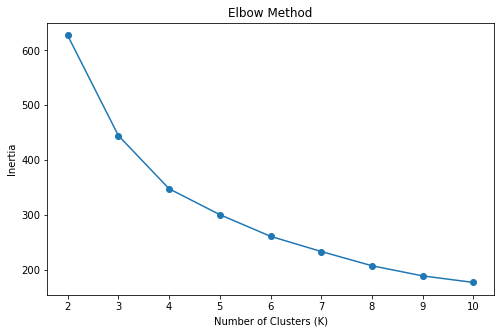

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [33]:
silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

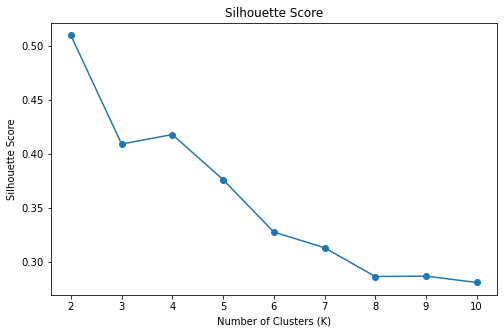

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [35]:
optimal_k = 3
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
kmeans.fit(X_scaled)
df["Cluster"] = kmeans.labels_

In [36]:
display(df.head())

,CustomerID,Age,Annual_Income,Spending_Score,Cluster
0,C0001,55.0,152523.0,38.0,0
1,C0002,35.0,58321.0,61.0,2
2,C0003,30.0,93809.0,69.0,1
3,C0004,48.0,80737.0,42.0,2
4,C0005,27.0,56140.0,62.0,1


In [37]:
#Analyze Each Cluster
cluster_profile = df.groupby(
    "Cluster"
)[features].mean()

print(cluster_profile)

               Age  Annual_Income  Spending_Score
Cluster                                          
0        51.867133  121761.769231       28.174825
1        28.444444   48675.116162       76.116162
2        40.968553   72107.641509       53.226415


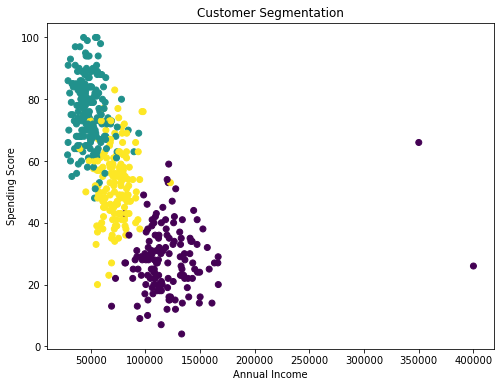

In [38]:
#visualize clusters:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [39]:
#cluster centers
kmeans.cluster_centers_

array([[ 1.09701238,  1.2107242 , -1.20370879],
       [-0.91968264, -0.76743757,  0.93747461],
       [ 0.15864397, -0.13321335, -0.08484035]])

In [40]:
# These are the centroids in scaled feature space because we trained using X_scaled.
# To convert them back to the original units:

centers_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    centers_original,
    columns=features
)

print(centers_df)

         Age  Annual_Income  Spending_Score
0  51.867133  121761.769231       28.174825
1  28.444444   48675.116162       76.116162
2  40.968553   72107.641509       53.226415


In [41]:
joblib.dump(
    kmeans,
    "customer_segmentation_kmeans.pkl"
)

['customer_segmentation_kmeans.pkl']

In [42]:
loaded_pipeline = joblib.load(
    "customer_segmentation_kmeans.pkl"
)

In [43]:
new_customer = pd.DataFrame({
    "Age": [30],
    "Annual_Income": [60000],
    "Spending_Score": [75]
})

In [44]:
cluster = loaded_pipeline.predict(
    new_customer
)

print("Customer belongs to cluster:", cluster[0])

Customer belongs to cluster: 0


C:\Users\Monika Dogra\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


In [45]:
# Production pipeline code:
# from sklearn.pipeline import Pipeline

# pipeline = Pipeline([
#     (
#         "scaler",
#         StandardScaler()
#     ),
#     (
#         "kmeans",
#         KMeans(
#             n_clusters=3,
#             random_state=42,
#             n_init=10
#         )
#     )
# ])

# # Fit pipeline
# pipeline.fit(X)
# clusters = pipeline.predict(X)
# df["Cluster"] = kmeans.labels_
# cluster_profile = df.groupby(
#     "Cluster"
# )[features].mean()

# display(cluster_profile)